# Système de recommandation agricole - Modélisation

## Librairies nécessaires

In [1]:
# Import de base
import pandas as pd
import numpy as np
import sys,os, joblib, shap
import matplotlib.pyplot as plt
import logging
sys.path.append(os.path.abspath(".."))

# Import scikit learn
from sklearn.model_selection import (train_test_split, KFold, cross_validate, GridSearchCV)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor

# Import des autres modèles testés
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")
warnings.filterwarnings("ignore", message="Hint: Inferred schema contains integer")
warnings.filterwarnings("ignore", message="Saving scikit-learn models")

# Import mlflow
import mlflow
mlflow.set_tracking_uri("file://" + os.path.abspath("../mlruns"))
from mlflow.tracking import MlflowClient
from mlflow.models.signature import infer_signature
# Warning pickle/sklearn de MLflow
logging.getLogger("mlflow.sklearn").setLevel(logging.ERROR)
# Import du projet
from scripts.preprocessing_pipeline import (
    separation_X_y,
    preparation_pipeline,
    cross_validation,
    train_predict
)
from scripts.config import (csv_yield_conso, csv_yield_enriched)

/Users/florianschorer/Library/Caches/pypoetry/virtualenvs/systeme-recommandation-agricole-5e-JMIdX-py3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Comparaison modèle sans optimisation sur le fichier consolidé

In [20]:
def mlflow_tracking_model(model, model_name, tags, projet_description):
    # =====================
    # Configuration MLflow
    mlflow.set_tracking_uri("http://127.0.0.1:5000")
    mlflow.set_experiment("Agritech_Answers")

    reg_name = "Yield_Forecaster_Global"
    mlflow.sklearn.autolog(log_models=False, log_datasets=False, silent=True)

    # =======================
    # Chargement des données
    # Dataset préparé mais non encodé
    df = pd.read_csv(csv_yield_conso)

    with mlflow.start_run(run_name=model_name, tags={
        "Training Info": tags,
        "Algorithm": model.__class__.__name__,
        "mlflow.note.content": projet_description
    }) as run:

        X_train, X_test, y_train, y_test, categorical_cols, numeric_cols = separation_X_y(df)

        # Pipeline & Cross-Validation
        pipeline = preparation_pipeline(
            numeric_cols=numeric_cols,
            categorical_cols=categorical_cols,
            model=model
        )
        cv_results = cross_validation(pipeline=pipeline, X_train=X_train, y_train=y_train)

        # On divise par 10 pour avoir les informations en kg (actuellement en hg)
        cv_metrics = {
            "cv_rmse_mean_kg": np.sqrt(-cv_results["test_mse"]).mean() / 10,
            "cv_rmse_std_kg": np.sqrt(-cv_results["test_mse"]).std() / 10,
            "cv_mae_mean_kg": (-cv_results["test_mae"]).mean() / 10,
            "cv_mae_std_kg": (-cv_results["test_mae"]).std() / 10,
            "cv_mape_mean": (-cv_results["test_mape"]).mean(),
            "cv_mape_std": (-cv_results["test_mape"]).std(),
            "cv_r2_mean": cv_results["test_r2"].mean(),
            "cv_r2_std": cv_results["test_r2"].std()
            }
        mlflow.log_metrics(cv_metrics)

        # Entraînement final
        pipeline.fit(X_train, y_train)

        # Prédictions test
        y_pred = pipeline.predict(X_test)

        # Prix moyen au global tiré d'un fichier officiel - FAO
        prices_fao = {
            "cassava": 270, "maize": 260, "plantains_and_others": 480, "potatoes": 330,
            "rice": 360, "sorghum": 230, "soybean": 400, "sweet_potatoes": 420,
            "wheat": 200, "yams": 890, "barley": 220
        }
        # Construction d'un dataframe pour y extraire ligne à ligne par la suite
        results_df = pd.DataFrame({
            "actual": y_test,
            "pred": y_pred,
            "abs_error": np.abs(y_test - y_pred),
        }, index=X_test.index)

        # On récupère directement la culture brute
        results_df["crop"] = (
            X_test.loc[results_df.index, "item"]
            .astype(str)
            .str.strip()
            .str.lower()
        )
        # Calcul du R2 par item
        r2_by_item = results_df.groupby("crop").apply(
            lambda g: r2_score(g["actual"], g["pred"]) if len(g) > 1 else np.nan, include_groups=False
            ).dropna()
        
        # Calcul du MAPE par item
        mape_by_item = results_df.groupby("crop").apply(
            lambda g: mean_absolute_percentage_error(g["actual"], g["pred"]) if len(g) > 1 else np.nan, include_groups=False
            ).dropna()        
        # Enregistrement des métriques
        mlflow.log_metrics({f"test_r2_{crop}": float(r2)for crop, r2 in r2_by_item.items()})
        mlflow.log_metrics({f"test_mape_{crop}": float(mape)for crop, mape in mape_by_item.items()})

        # Calcul du coût économique
        def calculate_monetary_error(row):
            price = prices_fao.get(row["crop"], 250)
            return (row["abs_error"] / 10000) * price

        results_df["error_cost_usd_ha"] = results_df.apply(calculate_monetary_error, axis=1)
        # Par crop
        economic_error_by_crop = (results_df.groupby("crop")["error_cost_usd_ha"].mean().sort_values())

        mlflow.log_metrics({f"test_economic_error_usd_ha_{crop}": float(cost)
                            for crop, cost in economic_error_by_crop.items()
                            })
        # Au total
        mean_economic_error = results_df["error_cost_usd_ha"].mean()

        rmse_hg = np.sqrt(mean_squared_error(y_test, y_pred))
        mae_hg = mean_absolute_error(y_test, y_pred)
        test_metrics = {
            "test_rmse_kg": rmse_hg / 10,
            "test_mae_kg": mae_hg / 10,
            "test_mape": mean_absolute_percentage_error(y_test, y_pred),
            "test_r2": r2_score(y_test, y_pred),
            "economic_error_usd_ha": mean_economic_error
        }
        mlflow.log_metrics(test_metrics)

        signature = infer_signature(X_test, y_pred)
        model_info = mlflow.sklearn.log_model(
            sk_model=pipeline,
            name="model",
            signature=signature,
            registered_model_name=reg_name
        )

        client = MlflowClient()
        mv = model_info.registered_model_version

        full_description = (
            f"**Modèle :** {model_name}\n"
            f"**Note :** {projet_description}\n\n"
            f"**Scores CV (Moyenne ± Écart-type) :**\n"
            f"- CV R2: {cv_metrics['cv_r2_mean']:.4f} (± {cv_metrics['cv_r2_std']:.4f})\n"
            f"- CV RMSE: {cv_metrics['cv_rmse_mean_kg']:.2f} (± {cv_metrics['cv_rmse_std_kg']:.2f})\n\n"
            f"**Scores Test :**\n"
            f"- Test R2: {test_metrics['test_r2']:.4f}\n"
            f"- Test economic_error_usd_ha: {test_metrics['economic_error_usd_ha']:.4f}\n"
        )

        client.update_model_version(name=reg_name, version=mv, description=full_description)
        client.set_model_version_tag(reg_name, mv, "Algo", model.__class__.__name__)
        client.set_model_version_tag(reg_name, mv, "CV_R2", round(cv_metrics["cv_r2_mean"], 4))
        client.set_model_version_tag(reg_name, mv, "CV_Std", round(cv_metrics["cv_r2_std"], 4))
        

        print(f"\nVersion {mv} enregistrée.")
        print("\n=== Résultats métriques ===")
        print(f"CV RMSE : {cv_metrics['cv_rmse_mean_kg']:.4f} (± {cv_metrics['cv_rmse_std_kg']:.2f})")
        print(f"CV MAPE  : {cv_metrics['cv_mape_mean']:.4f} (± {cv_metrics['cv_mape_std']:.4f})")
        print(f"CV R2   : {cv_metrics['cv_r2_mean']:.4f} (± {cv_metrics['cv_r2_std']:.4f})")
        print(f"Test RMSE : {test_metrics['test_rmse_kg']:.4f}")
        print(f"Test R2   : {test_metrics['test_r2']:.4f}")
        print(f"Test MAPE  : {test_metrics['test_mape']:.4f}")
        print(f"Test economic_error_usd_ha : {test_metrics['economic_error_usd_ha']:.4f}\n")

In [13]:
# DummyRegressor
model = DummyRegressor()
model_name = "DummyRegressor - Baseline"
tags = "DummyRegressor - Baseline"
projet_description = "Test d'un modèle DummyRegressor pour avoir une base sur laquelle comparer"
mlflow_tracking_model(model, model_name, tags, projet_description)

2026-04-12 08:49:59,181 - INFO - Colonnes numériques : ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'input_imbalance', 'thermal_stress', 'years_from_now']
2026-04-12 08:49:59,182 - INFO - Colonnes catégorielles : ['region', 'item', 'is_drought']
Successfully registered model 'Yield_Forecaster_Global'.
2026/04/12 08:50:03 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Yield_Forecaster_Global, version 1



Version 1 enregistrée.

=== Résultats métriques ===
CV RMSE : 7604.3730 (± 187.80)
CV MAPE  : 2.6730 (± 0.1885)
CV R2   : -0.0002 (± 0.0002)
Test RMSE : 7216.6343
Test R2   : -0.0013
Test MAPE  : 2.4448
Test economic_error_usd_ha : 1680.7060

🏃 View run DummyRegressor - Baseline at: http://127.0.0.1:5000/#/experiments/5/runs/9c590a69132549ad912658af83cb30c4
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/5


Created version '1' of model 'Yield_Forecaster_Global'.


In [14]:
# Modèle de régression linéaire
model = LinearRegression()
model_name = "LinearRegression - Baseline"
tags = "LinearRegression - Baseline"
projet_description = "Test d'un modèle LinearRegression sans optimisation"
mlflow_tracking_model(model, model_name, tags, projet_description)


2026-04-12 08:50:39,180 - INFO - Colonnes numériques : ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'input_imbalance', 'thermal_stress', 'years_from_now']
2026-04-12 08:50:39,181 - INFO - Colonnes catégorielles : ['region', 'item', 'is_drought']
Registered model 'Yield_Forecaster_Global' already exists. Creating a new version of this model...
2026/04/12 08:50:44 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Yield_Forecaster_Global, version 2



Version 2 enregistrée.

=== Résultats métriques ===
CV RMSE : 4840.4290 (± 55.16)
CV MAPE  : 0.9546 (± 0.0388)
CV R2   : 0.5943 (± 0.0143)
Test RMSE : 4805.9227
Test R2   : 0.5559
Test MAPE  : 0.9859
Test economic_error_usd_ha : 1033.3629

🏃 View run LinearRegression - Baseline at: http://127.0.0.1:5000/#/experiments/5/runs/871688843f8347a08019ae537790c430
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/5


Created version '2' of model 'Yield_Forecaster_Global'.


In [15]:
# Modèle de RandomForest
model = RandomForestRegressor(random_state=42)
model_name = "RandomForest - Baseline"
tags = "RandomForest - Baseline"
projet_description = "Test d'un modèle Random Forest sans optimisation"
mlflow_tracking_model(model, model_name, tags, projet_description)


2026-04-12 08:50:53,242 - INFO - Colonnes numériques : ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'input_imbalance', 'thermal_stress', 'years_from_now']
2026-04-12 08:50:53,242 - INFO - Colonnes catégorielles : ['region', 'item', 'is_drought']
Registered model 'Yield_Forecaster_Global' already exists. Creating a new version of this model...
2026/04/12 08:53:12 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Yield_Forecaster_Global, version 3
Created version '3' of model 'Yield_Forecaster_Global'.



Version 3 enregistrée.

=== Résultats métriques ===
CV RMSE : 1893.0226 (± 45.34)
CV MAPE  : 0.2091 (± 0.0098)
CV R2   : 0.9378 (± 0.0051)
Test RMSE : 1729.6763
Test R2   : 0.9425
Test MAPE  : 0.1739
Test economic_error_usd_ha : 273.6834

🏃 View run RandomForest - Baseline at: http://127.0.0.1:5000/#/experiments/5/runs/1c3f33cbdb7a486995cbb441297fd81e
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/5


In [16]:
# Modèle de XGBoost
model = xgb.XGBRegressor(random_state=42)
model_name = "XGBRegressor - Baseline"
tags = "XGBRegressor - Baseline"
projet_description = "Test d'un modèle XGBRegressor sans optimisation"
mlflow_tracking_model(model, model_name, tags, projet_description)


2026-04-12 08:53:58,395 - INFO - Colonnes numériques : ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'input_imbalance', 'thermal_stress', 'years_from_now']
2026-04-12 08:53:58,396 - INFO - Colonnes catégorielles : ['region', 'item', 'is_drought']
Registered model 'Yield_Forecaster_Global' already exists. Creating a new version of this model...
2026/04/12 08:54:04 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Yield_Forecaster_Global, version 4



Version 4 enregistrée.

=== Résultats métriques ===
CV RMSE : 2152.0037 (± 71.11)
CV MAPE  : 0.3938 (± 0.0186)
CV R2   : 0.9195 (± 0.0082)
Test RMSE : 2040.8158
Test R2   : 0.9199
Test MAPE  : 0.3603
Test economic_error_usd_ha : 406.6547

🏃 View run XGBRegressor - Baseline at: http://127.0.0.1:5000/#/experiments/5/runs/4d8e7f0cc79d4d7cbbe9685a5a1ccd3a
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/5


Created version '4' of model 'Yield_Forecaster_Global'.


In [17]:
# Modèle de LightGBM
model = lgb.LGBMRegressor(random_state=42, verbose=-1)
model_name = "LGBMRegressor - Baseline"
tags = "LGBMRegressor - Baseline"
projet_description = "Test d'un modèle LGBMRegressor sans optimisation"
mlflow_tracking_model(model, model_name, tags, projet_description)


2026-04-12 08:54:10,602 - INFO - Colonnes numériques : ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'input_imbalance', 'thermal_stress', 'years_from_now']
2026-04-12 08:54:10,602 - INFO - Colonnes catégorielles : ['region', 'item', 'is_drought']
Registered model 'Yield_Forecaster_Global' already exists. Creating a new version of this model...
2026/04/12 08:54:19 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Yield_Forecaster_Global, version 5



Version 5 enregistrée.

=== Résultats métriques ===
CV RMSE : 2689.7368 (± 50.00)
CV MAPE  : 0.5493 (± 0.0383)
CV R2   : 0.8745 (± 0.0095)
Test RMSE : 2679.5389
Test R2   : 0.8620
Test MAPE  : 0.5107
Test economic_error_usd_ha : 551.5749

🏃 View run LGBMRegressor - Baseline at: http://127.0.0.1:5000/#/experiments/5/runs/b29dcd3b524e4853a8ae6db900a8327e
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/5


Created version '5' of model 'Yield_Forecaster_Global'.


- Sur ces premiers tests, le modèle qui s'en sort le mieux sur l'ensemble des métriques (performance et métier) c'est celui de Random Forest.
- Les résultats de XGBoost et LightGBM sont exploitables pour essayer d'améliorer leur performance.
- Par contre le modèle de régression linéaire est trop loin en terme de performance. Au vu de la distribution de notre varibale cible, cela n'est pas étonnant.

# Comparaison modèle sans optimisation sur le fichier enrichi

In [2]:
def mlflow_tracking_model(model, model_name, tags, projet_description):
    # =====================
    # Configuration MLflow
    mlflow.set_tracking_uri("http://127.0.0.1:5000")
    mlflow.set_experiment("Agritech_Answers")

    reg_name = "Yield_Forecaster_Global"
    mlflow.sklearn.autolog(log_models=False, log_datasets=False, silent=True)

    # =======================
    # Chargement des données
    # Dataset préparé mais non encodé
    df = pd.read_csv(csv_yield_enriched)

    with mlflow.start_run(run_name=model_name, tags={
        "Training Info": tags,
        "Algorithm": model.__class__.__name__,
        "mlflow.note.content": projet_description
    }) as run:

        X_train, X_test, y_train, y_test, categorical_cols, numeric_cols = separation_X_y(df)

        # Pipeline & Cross-Validation
        pipeline = preparation_pipeline(
            numeric_cols=numeric_cols,
            categorical_cols=categorical_cols,
            model=model
        )
        cv_results = cross_validation(pipeline=pipeline, X_train=X_train, y_train=y_train)

        # On divise par 10 pour avoir les informations en kg (actuellement en hg)
        cv_metrics = {
            "cv_rmse_mean_kg": np.sqrt(-cv_results["test_mse"]).mean() / 10,
            "cv_rmse_std_kg": np.sqrt(-cv_results["test_mse"]).std() / 10,
            "cv_mae_mean_kg": (-cv_results["test_mae"]).mean() / 10,
            "cv_mae_std_kg": (-cv_results["test_mae"]).std() / 10,
            "cv_mape_mean": (-cv_results["test_mape"]).mean(),
            "cv_mape_std": (-cv_results["test_mape"]).std(),
            "cv_r2_mean": cv_results["test_r2"].mean(),
            "cv_r2_std": cv_results["test_r2"].std()
            }
        mlflow.log_metrics(cv_metrics)

        # Entraînement final
        pipeline.fit(X_train, y_train)

        # Prédictions test
        y_pred = pipeline.predict(X_test)

        # Prix moyen au global tiré d'un fichier officiel - FAO
        prices_fao = {
            "cassava": 270, "maize": 260, "plantains_and_others": 480, "potatoes": 330,
            "rice": 360, "sorghum": 230, "soybean": 400, "sweet_potatoes": 420,
            "wheat": 200, "yams": 890, "barley": 220
        }
        # Construction d'un dataframe pour y extraire ligne à ligne par la suite
        results_df = pd.DataFrame({
            "actual": y_test,
            "pred": y_pred,
            "abs_error": np.abs(y_test - y_pred),
        }, index=X_test.index)

        # On récupère directement la culture brute
        results_df["crop"] = (
            X_test.loc[results_df.index, "item"]
            .astype(str)
            .str.strip()
            .str.lower()
        )
        # Calcul du R2 par item
        r2_by_item = results_df.groupby("crop").apply(
            lambda g: r2_score(g["actual"], g["pred"]) if len(g) > 1 else np.nan, include_groups=False
            ).dropna()
        
        # Calcul du MAPE par item
        mape_by_item = results_df.groupby("crop").apply(
            lambda g: mean_absolute_percentage_error(g["actual"], g["pred"]) if len(g) > 1 else np.nan, include_groups=False
            ).dropna()        
        # Enregistrement des métriques
        mlflow.log_metrics({f"test_r2_{crop}": float(r2)for crop, r2 in r2_by_item.items()})
        mlflow.log_metrics({f"test_mape_{crop}": float(mape)for crop, mape in mape_by_item.items()})

        # Calcul du coût économique
        def calculate_monetary_error(row):
            price = prices_fao.get(row["crop"], 250)
            return (row["abs_error"] / 10000) * price

        results_df["error_cost_usd_ha"] = results_df.apply(calculate_monetary_error, axis=1)
        # Par crop
        economic_error_by_crop = (results_df.groupby("crop")["error_cost_usd_ha"].mean().sort_values())

        mlflow.log_metrics({f"test_economic_error_usd_ha_{crop}": float(cost)
                            for crop, cost in economic_error_by_crop.items()
                            })
        # Au total
        mean_economic_error = results_df["error_cost_usd_ha"].mean()

        rmse_hg = np.sqrt(mean_squared_error(y_test, y_pred))
        mae_hg = mean_absolute_error(y_test, y_pred)
        test_metrics = {
            "test_rmse_kg": rmse_hg / 10,
            "test_mae_kg": mae_hg / 10,
            "test_mape": mean_absolute_percentage_error(y_test, y_pred),
            "test_r2": r2_score(y_test, y_pred),
            "economic_error_usd_ha": mean_economic_error
        }
        mlflow.log_metrics(test_metrics)

        signature = infer_signature(X_test, y_pred)
        model_info = mlflow.sklearn.log_model(
            sk_model=pipeline,
            name="model",
            signature=signature,
            registered_model_name=reg_name
        )

        client = MlflowClient()
        mv = model_info.registered_model_version

        full_description = (
            f"**Modèle :** {model_name}\n"
            f"**Note :** {projet_description}\n\n"
            f"**Scores CV (Moyenne ± Écart-type) :**\n"
            f"- CV R2: {cv_metrics['cv_r2_mean']:.4f} (± {cv_metrics['cv_r2_std']:.4f})\n"
            f"- CV RMSE: {cv_metrics['cv_rmse_mean_kg']:.2f} (± {cv_metrics['cv_rmse_std_kg']:.2f})\n\n"
            f"**Scores Test :**\n"
            f"- Test R2: {test_metrics['test_r2']:.4f}\n"
            f"- Test economic_error_usd_ha: {test_metrics['economic_error_usd_ha']:.4f}\n"
        )

        client.update_model_version(name=reg_name, version=mv, description=full_description)
        client.set_model_version_tag(reg_name, mv, "Algo", model.__class__.__name__)
        client.set_model_version_tag(reg_name, mv, "CV_R2", round(cv_metrics["cv_r2_mean"], 4))
        client.set_model_version_tag(reg_name, mv, "CV_Std", round(cv_metrics["cv_r2_std"], 4))
        

        print(f"\nVersion {mv} enregistrée.")
        print("\n=== Résultats métriques ===")
        print(f"CV RMSE : {cv_metrics['cv_rmse_mean_kg']:.4f} (± {cv_metrics['cv_rmse_std_kg']:.2f})")
        print(f"CV MAPE  : {cv_metrics['cv_mape_mean']:.4f} (± {cv_metrics['cv_mape_std']:.4f})")
        print(f"CV R2   : {cv_metrics['cv_r2_mean']:.4f} (± {cv_metrics['cv_r2_std']:.4f})")
        print(f"Test RMSE : {test_metrics['test_rmse_kg']:.4f}")
        print(f"Test R2   : {test_metrics['test_r2']:.4f}")
        print(f"Test MAPE  : {test_metrics['test_mape']:.4f}")
        print(f"Test economic_error_usd_ha : {test_metrics['economic_error_usd_ha']:.4f}\n")

In [3]:
# DummyRegressor
model = DummyRegressor()
model_name = "DummyRegressor - Baseline - fichier enrichi"
tags = "DummyRegressor - Baseline - fichier enrichi"
projet_description = "Test d'un modèle DummyRegressor pour avoir une base sur laquelle comparer"
mlflow_tracking_model(model, model_name, tags, projet_description)

2026-04-12 09:01:09,645 - INFO - Colonnes numériques : ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'input_imbalance', 'thermal_stress', 'years_from_now']
2026-04-12 09:01:09,646 - INFO - Colonnes catégorielles : ['region', 'item', 'fertilizer_used', 'irrigation_used', 'weather_condition', 'soil_type', 'is_drought']
Registered model 'Yield_Forecaster_Global' already exists. Creating a new version of this model...
2026/04/12 09:01:16 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Yield_Forecaster_Global, version 6



Version 6 enregistrée.

=== Résultats métriques ===
CV RMSE : 7604.3730 (± 187.80)
CV MAPE  : 2.6730 (± 0.1885)
CV R2   : -0.0002 (± 0.0002)
Test RMSE : 7216.6343
Test R2   : -0.0013
Test MAPE  : 2.4448
Test economic_error_usd_ha : 1680.7060

🏃 View run DummyRegressor - Baseline - fichier enrichi at: http://127.0.0.1:5000/#/experiments/5/runs/f15a2b7071754947abb27685d1282e0e
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/5


Created version '6' of model 'Yield_Forecaster_Global'.


In [4]:
# Modèle de régression linéaire
model = LinearRegression()
model_name = "LinearRegression - Baseline - fichier enrichi"
tags = "LinearRegression - Baseline - fichier enrichi"
projet_description = "Test d'un modèle LinearRegression sans optimisation"
mlflow_tracking_model(model, model_name, tags, projet_description)


2026-04-12 09:01:24,808 - INFO - Colonnes numériques : ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'input_imbalance', 'thermal_stress', 'years_from_now']
2026-04-12 09:01:24,808 - INFO - Colonnes catégorielles : ['region', 'item', 'fertilizer_used', 'irrigation_used', 'weather_condition', 'soil_type', 'is_drought']
Registered model 'Yield_Forecaster_Global' already exists. Creating a new version of this model...
2026/04/12 09:01:30 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Yield_Forecaster_Global, version 7



Version 7 enregistrée.

=== Résultats métriques ===
CV RMSE : 4841.7110 (± 54.37)
CV MAPE  : 0.9555 (± 0.0386)
CV R2   : 0.5941 (± 0.0143)
Test RMSE : 4807.8225
Test R2   : 0.5556
Test MAPE  : 0.9849
Test economic_error_usd_ha : 1034.2202

🏃 View run LinearRegression - Baseline - fichier enrichi at: http://127.0.0.1:5000/#/experiments/5/runs/5704e47afdd842e58333e141750f025d
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/5


Created version '7' of model 'Yield_Forecaster_Global'.


In [5]:
# Modèle de RandomForest
model = RandomForestRegressor(random_state=42)
model_name = "RandomForest - Baseline - fichier enrichi"
tags = "RandomForest - Baseline"
projet_description = "Test d'un modèle Random Forest sans optimisation"
mlflow_tracking_model(model, model_name, tags, projet_description)


2026-04-12 09:01:37,118 - INFO - Colonnes numériques : ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'input_imbalance', 'thermal_stress', 'years_from_now']
2026-04-12 09:01:37,119 - INFO - Colonnes catégorielles : ['region', 'item', 'fertilizer_used', 'irrigation_used', 'weather_condition', 'soil_type', 'is_drought']
Registered model 'Yield_Forecaster_Global' already exists. Creating a new version of this model...
2026/04/12 09:05:12 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Yield_Forecaster_Global, version 8



Version 8 enregistrée.

=== Résultats métriques ===
CV RMSE : 1926.1649 (± 66.57)
CV MAPE  : 0.2276 (± 0.0102)
CV R2   : 0.9355 (± 0.0065)
Test RMSE : 1748.9721
Test R2   : 0.9412
Test MAPE  : 0.1982
Test economic_error_usd_ha : 291.8239

🏃 View run RandomForest - Baseline - fichier enrichi at: http://127.0.0.1:5000/#/experiments/5/runs/a071b5bdea9345c9b04d4ad003464fbc
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/5


Created version '8' of model 'Yield_Forecaster_Global'.


In [6]:
# Modèle de XGBoost
model = xgb.XGBRegressor(random_state=42)
model_name = "XGBRegressor - Baseline - fichier enrichi"
tags = "XGBRegressor - Baseline - fichier enrichi"
projet_description = "Test d'un modèle XGBRegressor sans optimisation"
mlflow_tracking_model(model, model_name, tags, projet_description)

2026-04-12 09:06:35,255 - INFO - Colonnes numériques : ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'input_imbalance', 'thermal_stress', 'years_from_now']
2026-04-12 09:06:35,255 - INFO - Colonnes catégorielles : ['region', 'item', 'fertilizer_used', 'irrigation_used', 'weather_condition', 'soil_type', 'is_drought']
Registered model 'Yield_Forecaster_Global' already exists. Creating a new version of this model...
2026/04/12 09:06:39 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Yield_Forecaster_Global, version 9



Version 9 enregistrée.

=== Résultats métriques ===
CV RMSE : 2179.0641 (± 44.71)
CV MAPE  : 0.3995 (± 0.0220)
CV R2   : 0.9175 (± 0.0072)
Test RMSE : 2017.5085
Test R2   : 0.9217
Test MAPE  : 0.3757
Test economic_error_usd_ha : 413.5231

🏃 View run XGBRegressor - Baseline - fichier enrichi at: http://127.0.0.1:5000/#/experiments/5/runs/d89fdce99f9b43ae87ad023c2c8ba077
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/5


Created version '9' of model 'Yield_Forecaster_Global'.


In [7]:
# Modèle de LightGBM
model = lgb.LGBMRegressor(random_state=42, verbose=-1)
model_name = "LGBMRegressor - Baseline - fichier enrichi"
tags = "LGBMRegressor - Baselzine - fichier enrichi"
projet_description = "Test d'un modèle LGBMRegressor sans optimisation"
mlflow_tracking_model(model, model_name, tags, projet_description)

2026-04-12 09:06:43,463 - INFO - Colonnes numériques : ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'input_imbalance', 'thermal_stress', 'years_from_now']
2026-04-12 09:06:43,464 - INFO - Colonnes catégorielles : ['region', 'item', 'fertilizer_used', 'irrigation_used', 'weather_condition', 'soil_type', 'is_drought']
Registered model 'Yield_Forecaster_Global' already exists. Creating a new version of this model...
2026/04/12 09:06:52 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Yield_Forecaster_Global, version 10



Version 10 enregistrée.

=== Résultats métriques ===
CV RMSE : 2709.1046 (± 52.11)
CV MAPE  : 0.5443 (± 0.0350)
CV R2   : 0.8726 (± 0.0101)
Test RMSE : 2677.7113
Test R2   : 0.8621
Test MAPE  : 0.5128
Test economic_error_usd_ha : 553.9541

🏃 View run LGBMRegressor - Baseline - fichier enrichi at: http://127.0.0.1:5000/#/experiments/5/runs/a6066be51e0c4f49b5d7a6478e5b9514
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/5


Created version '10' of model 'Yield_Forecaster_Global'.


# Optimisation des hyperparamètres sur RandomForest

A l'aide de gridsearchCV, on va essayer ici de trouver les meilleurs hyperparamètres pour chacun des modèles

In [2]:
def mlflow_tracking_gridsearch(model, model_name, param_grid, tags, projet_description):
    # =====================
    # Configuration MLflow
    mlflow.set_tracking_uri("http://127.0.0.1:5000")
    mlflow.set_experiment("Agritech_Answers")

    reg_name = "Yield_Forecaster_Global"
    mlflow.sklearn.autolog(log_models=False, log_datasets=False, silent=True, max_tuning_runs=0)

    # =======================
    # Chargement des données
    df = pd.read_csv(csv_yield_conso)

    with mlflow.start_run(run_name=model_name, tags={
        "Training Info": tags,
        "Algorithm": model.__class__.__name__,
        "mlflow.note.content": projet_description
    }) as run:

        mlflow.set_tag("target_raw_unit", "hg/ha")
        mlflow.set_tag("logged_metric_unit", "kg/ha")
        mlflow.set_tag("economic_metric_unit", "usd/ha")

        X_train, X_test, y_train, y_test, categorical_cols, numeric_cols = separation_X_y(df)

        # Pipeline & GridSearch
        pipeline = preparation_pipeline(
            numeric_cols=numeric_cols,
            categorical_cols=categorical_cols,
            model=model
        )

        cv = KFold(n_splits=5, shuffle=True, random_state=42)

        grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            scoring="r2",
            n_jobs=-1,
            cv=cv,
            refit=True,
            error_score="raise"
        )

        grid_search.fit(X_train, y_train)

        best_index = grid_search.best_index_

        cv_metrics = {
            "best_cv_r2_mean": grid_search.best_score_,
            "best_cv_r2_std": grid_search.cv_results_["std_test_score"][best_index]
        }

        mlflow.log_params(grid_search.best_params_)
        mlflow.log_metrics(cv_metrics)

        # Entraînement final déjà fait par refit=True
        best_pipeline = grid_search.best_estimator_

        # Prédictions test
        y_pred = best_pipeline.predict(X_test)

               # Prix moyen au global tiré d'un fichier officiel - FAO
        prices_fao = {
            "cassava": 270, "maize": 260, "plantains_and_others": 480, "potatoes": 330,
            "rice": 360, "sorghum": 230, "soybean": 400, "sweet_potatoes": 420,
            "wheat": 200, "yams": 890, "barley": 220
        }
        # Construction d'un dataframe pour y extraire ligne à ligne par la suite
        results_df = pd.DataFrame({
            "actual": y_test,
            "pred": y_pred,
            "abs_error": np.abs(y_test - y_pred),
        }, index=X_test.index)

        # On récupère directement la culture brute
        results_df["crop"] = (
            X_test.loc[results_df.index, "item"]
            .astype(str)
            .str.strip()
            .str.lower()
        )
        # Calcul du R2 par item
        r2_by_item = results_df.groupby("crop").apply(
            lambda g: r2_score(g["actual"], g["pred"]) if len(g) > 1 else np.nan, include_groups=False
            ).dropna()
        
        # Calcul du MAPE par item
        mape_by_item = results_df.groupby("crop").apply(
            lambda g: mean_absolute_percentage_error(g["actual"], g["pred"]) if len(g) > 1 else np.nan, include_groups=False
            ).dropna()        
        # Enregistrement des métriques
        mlflow.log_metrics({f"test_r2_{crop}": float(r2)for crop, r2 in r2_by_item.items()})
        mlflow.log_metrics({f"test_mape_{crop}": float(mape)for crop, mape in mape_by_item.items()})

        # Calcul du coût économique
        def calculate_monetary_error(row):
            price = prices_fao.get(row["crop"], 250)
            return (row["abs_error"] / 10000) * price

        results_df["error_cost_usd_ha"] = results_df.apply(calculate_monetary_error, axis=1)
        # Par crop
        economic_error_by_crop = (results_df.groupby("crop")["error_cost_usd_ha"].mean().sort_values())

        mlflow.log_metrics({f"test_economic_error_usd_ha_{crop}": float(cost)
                            for crop, cost in economic_error_by_crop.items()
                            })
        # Au total
        mean_economic_error = results_df["error_cost_usd_ha"].mean()

        rmse_hg = np.sqrt(mean_squared_error(y_test, y_pred))
        mae_hg = mean_absolute_error(y_test, y_pred)
        test_metrics = {
            "test_rmse_kg": rmse_hg / 10,
            "test_mae_kg": mae_hg / 10,
            "test_mape": mean_absolute_percentage_error(y_test, y_pred),
            "test_r2": r2_score(y_test, y_pred),
            "economic_error_usd_ha": mean_economic_error
        }
        mlflow.log_metrics(test_metrics)

        signature = infer_signature(X_test, y_pred)

        model_info = mlflow.sklearn.log_model(
            sk_model=best_pipeline,
            name="model",
            signature=signature,
            registered_model_name=reg_name
        )

        client = MlflowClient()
        mv = model_info.registered_model_version

        full_description = (
            f"**Modèle Optimisé :** {model_name}\n"
            f"**Note :** {projet_description}\n\n"
            f"**Scores CV :**\n"
            f"- Best CV R2: {cv_metrics['best_cv_r2_mean']:.4f} "
            f"(± {cv_metrics['best_cv_r2_std']:.4f})\n\n"
            f"**Scores Test :**\n"
            f"- Test R2: {test_metrics['test_r2']:.4f}\n"
            f"- Test RMSE (kg/ha): {test_metrics['test_rmse_kg']:.2f}\n"
            f"- Test MAE (kg/ha): {test_metrics['test_mae_kg']:.2f}\n"
            f"- Test MAPE: {test_metrics['test_mape']:.2%}\n"
            f"- Test economic_error_usd_ha: {test_metrics['economic_error_usd_ha']:.4f}\n"
        )

        client.update_model_version(name=reg_name, version=mv, description=full_description)
        client.set_model_version_tag(reg_name, mv, "Algo", model.__class__.__name__)
        client.set_model_version_tag(reg_name, mv, "Best_CV_R2", round(cv_metrics["best_cv_r2_mean"], 4))
        client.set_model_version_tag(reg_name, mv, "Best_CV_Std", round(cv_metrics["best_cv_r2_std"], 4))
        client.set_model_version_tag(reg_name, mv, "Test_RMSE_kg_ha", round(test_metrics["test_rmse_kg"], 2))
        client.set_model_version_tag(reg_name, mv, "Test_MAPE", round(test_metrics["test_mape"],2))

        print(f"\nVersion {mv} enregistrée.")
        print("\n=== Résultats métriques ===")
        print(f"Best CV R2         : {cv_metrics['best_cv_r2_mean']:.4f} (± {cv_metrics['best_cv_r2_std']:.4f})")
        print(f"Test RMSE (kg/ha)  : {test_metrics['test_rmse_kg']:.4f}")
        print(f"Test R2            : {test_metrics['test_r2']:.4f}")
        print(f"Test MAPE          : {test_metrics['test_mape']:.2%}")
        print(f"Test economic_error_usd_ha : {test_metrics['economic_error_usd_ha']:.4f}\n")

        return {
            "best_pipeline": best_pipeline,
            "best_params": grid_search.best_params_,
            "test_metrics": test_metrics,
            "X_test": X_test,
            "y_test": y_test
        }

In [ ]:
 # Modèle de RandomForest
model = RandomForestRegressor(random_state=42, n_jobs=1)
model_name = "RandomForest - GridSearchCV"
param_grid = {
    'model__n_estimators': [200],
    'model__max_depth': [25],
    'model__min_samples_split': [2],
    'model__max_features': [0.7]
}
tags = "RandomForest - GridSearchCV"
projet_description = "L'objectif est de trouver les meilleurs paramètres possibles pour ce modèle"
results = mlflow_tracking_gridsearch(model, model_name,param_grid, tags, projet_description)

best_pipeline = results["best_pipeline"]

# Sauvegarde explicite du meilleur pipeline pour SHAP plus tard
joblib.dump(best_pipeline, "../model/randomforest_best_pipeline.joblib")

print("Pipeline sauvegardé : ../model/randomforest_best_pipeline.joblib")
print("Best params :", results["best_params"])

2026-04-12 09:54:25,072 - INFO - Colonnes numériques : ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'input_imbalance', 'thermal_stress', 'years_from_now']
2026-04-12 09:54:25,073 - INFO - Colonnes catégorielles : ['region', 'item', 'is_drought']
Registered model 'Yield_Forecaster_Global' already exists. Creating a new version of this model...
2026/04/12 09:57:30 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Yield_Forecaster_Global, version 11
Created version '11' of model 'Yield_Forecaster_Global'.



Version 11 enregistrée.

=== Résultats métriques ===
Best CV R2         : 0.9397 (± 0.0055)
Test RMSE (kg/ha)  : 1712.4748
Test R2            : 0.9436
Test MAPE          : 17.75%
Test economic_error_usd_ha : 274.4312

🏃 View run RandomForest - GridSearchCV at: http://127.0.0.1:5000/#/experiments/5/runs/5d7e084d2b0b43bba6d7d2a9802d8a11
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/5
Pipeline sauvegardé : ../model/randomforest_best_pipeline.joblib
Best params : {'model__max_depth': 25, 'model__max_features': 0.7, 'model__min_samples_split': 2, 'model__n_estimators': 200}


In [6]:
 # Modèle de RandomForest
model = RandomForestRegressor(random_state=42, n_jobs=2)
model_name = "RandomForest - GridSearchCV"
param_grid = {
    'model__n_estimators': [800, 1000],
    'model__max_depth': [15, 20],
    'model__min_samples_split': [2],
    'model__max_features': [0.5, 0.7]
}
tags = "RandomForest - GridSearchCV"
projet_description = "L'objectif est de trouver les meilleurs paramètres possibles pour ce modèle"
results = mlflow_tracking_gridsearch(model, model_name,param_grid, tags, projet_description)


2026-04-12 11:35:02,056 - INFO - Colonnes numériques : ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'input_imbalance', 'thermal_stress', 'years_from_now']
2026-04-12 11:35:02,057 - INFO - Colonnes catégorielles : ['region', 'item', 'is_drought']
/Users/florianschorer/Library/Caches/pypoetry/virtualenvs/systeme-recommandation-agricole-5e-JMIdX-py3.12/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Registered model 'Yield_Forecaster_Global' already exists. Creating a new version of this model...
2026/04/12 11:55:11 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Yield_Forecaster_Global, version 13
Created version '13' of model 'Yield_Forecaster_Global'.



Version 13 enregistrée.

=== Résultats métriques ===
Best CV R2         : 0.9395 (± 0.0055)
Test RMSE (kg/ha)  : 1742.5981
Test R2            : 0.9416
Test MAPE          : 21.18%
Test economic_error_usd_ha : 296.9744

🏃 View run RandomForest - GridSearchCV at: http://127.0.0.1:5000/#/experiments/5/runs/0d9d2e71cdf74021b45f2a35528b8887
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/5


# Feature importance


Top 15 features :
                                  feature  importance
0                      cat__item_Potatoes    0.314446
1                  num__pesticides_tonnes    0.095353
2                        num__rainfall_mm    0.085711
3                    num__input_imbalance    0.050120
4              cat__region_Western Europe    0.049183
5                cat__item_Sweet potatoes    0.043271
6                       cat__item_Cassava    0.042040
7                           num__avg_temp    0.037829
8                     num__years_from_now    0.037794
9                     num__thermal_stress    0.031121
10         cat__region_Sub-Saharan Africa    0.027085
11         cat__item_Plantains and others    0.023141
12                         cat__item_Yams    0.021330
13                      cat__item_Sorghum    0.014939
14  cat__region_Australia and New Zealand    0.014577


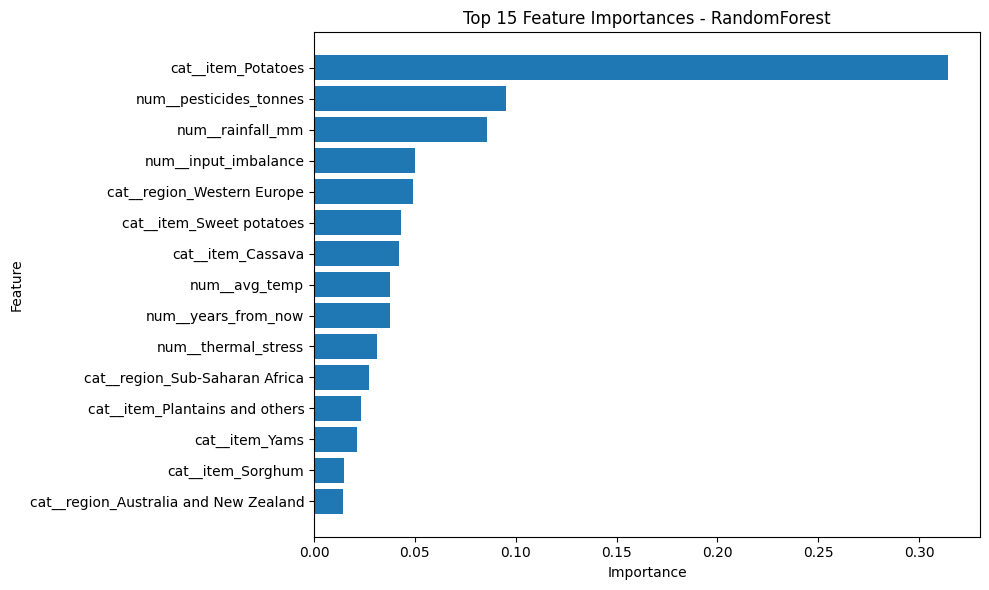


Importance par groupe :
                    group  importance
0                    item    0.493637
1                  region    0.165708
2  num__pesticides_tonnes    0.095353
3        num__rainfall_mm    0.085711
4    num__input_imbalance    0.050120
5           num__avg_temp    0.037829
6     num__years_from_now    0.037794
7     num__thermal_stress    0.031121
8              is_drought    0.002727


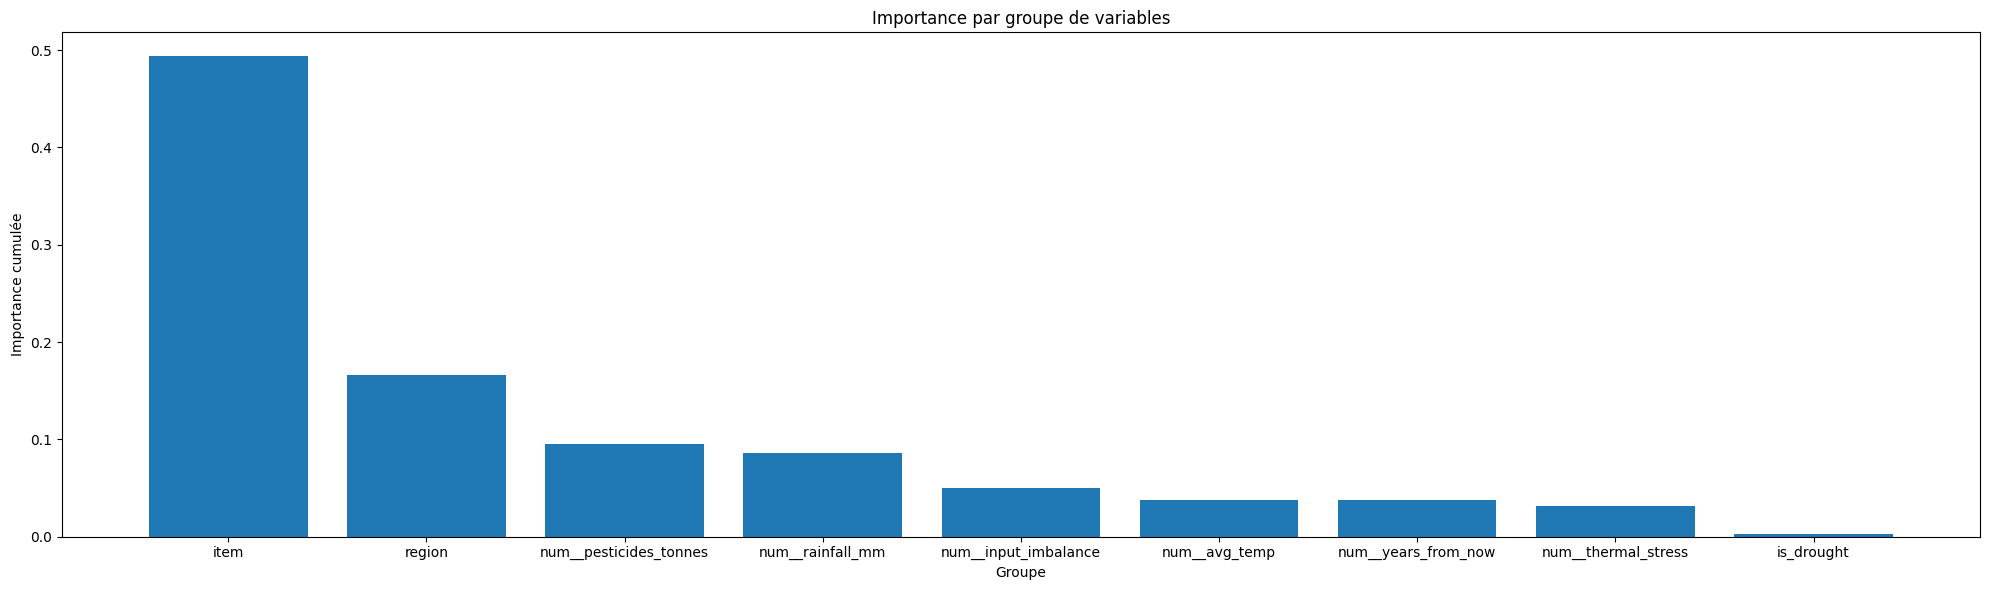

In [30]:
best_pipeline = joblib.load("../model/randomforest_best_pipeline.joblib")
# Extraire le modèle et le préprocesseur du pipeline
rf_model = best_pipeline.named_steps["model"]
preprocessor = best_pipeline.named_steps["preprocessor"]

# Récupérer les noms de variables après transformation
feature_names = preprocessor.get_feature_names_out()

# Récupérer les importances
importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("\nTop 15 features :")
print(feature_importance_df.head(15))

# Sauvegarder les importances

feature_importance_df.to_csv("../data/processed/feature_importance_random_forest.csv", index=False)

# Visualisation top 15

top_n = 15
top_features = feature_importance_df.head(top_n).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.title("Top 15 Feature Importances - RandomForest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Regrouper les variables par famille métier

def feature_group(feature_name: str) -> str:

    if "region_" in feature_name:
        return "region"
    
    if "item_" in feature_name:
        return "item"
    
    if "cat__is_drought" in feature_name:
        return "is_drought"
    
    return feature_name

feature_importance_df["group"] = feature_importance_df["feature"].apply(feature_group)

group_importance_df = (
    feature_importance_df
    .groupby("group", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("\nImportance par groupe :")
print(group_importance_df)

# Visualisation par groupe

plt.figure(figsize=(20, 6))
plt.bar(group_importance_df["group"], group_importance_df["importance"])
plt.title("Importance par groupe de variables")
plt.xlabel("Groupe")
plt.ylabel("Importance cumulée")
plt.tight_layout()
plt.show()

In [4]:
import os
import joblib
import shap
import pandas as pd
from sklearn.model_selection import train_test_split

ARTIFACT_DIR = "../model/shap_randomforest_sample"
PIPELINE_PATH = "../model/randomforest_best_pipeline.joblib"
DATA_PATH = "../data/processed/yield_df_final_conso.csv"

SAMPLE_SIZE = 2000
RANDOM_STATE = 42
TARGET_COL = "yield"
STRATIFY_COL = "item"

os.makedirs(ARTIFACT_DIR, exist_ok=True)

# Chargement pipeline + données
pipeline = joblib.load(PIPELINE_PATH)
df = pd.read_csv(DATA_PATH)

# Vérifications minimales
if TARGET_COL not in df.columns:
    raise ValueError(f"La colonne cible '{TARGET_COL}' est absente du dataset.")

if STRATIFY_COL not in df.columns:
    raise ValueError(f"La colonne de stratification '{STRATIFY_COL}' est absente du dataset.")

if SAMPLE_SIZE > len(df):
    raise ValueError(
        f"SAMPLE_SIZE={SAMPLE_SIZE} est supérieur au nombre de lignes disponibles ({len(df)})."
    )

# Variables explicatives brutes
X_full = df.drop(columns=[TARGET_COL]).copy()

# Échantillonnage stratifié sur item
# On échantillonne AVANT le preprocessing pour conserver la logique métier
X_sampled, _ = train_test_split(
    X_full,
    train_size=SAMPLE_SIZE,
    stratify=X_full[STRATIFY_COL],
    random_state=RANDOM_STATE,
)

# Préprocessing uniquement sur l'échantillon retenu
preprocessor = pipeline.named_steps["preprocessor"]
feature_names = preprocessor.get_feature_names_out()

X_shap_transformed = preprocessor.transform(X_sampled)

if hasattr(X_shap_transformed, "toarray"):
    X_shap_transformed = X_shap_transformed.toarray()

X_shap = pd.DataFrame(
    X_shap_transformed,
    columns=feature_names,
    index=X_sampled.index
)

# SHAP
model = pipeline.named_steps["model"]
explainer = shap.TreeExplainer(
    model,
    feature_perturbation="tree_path_dependent"
)

shap_values = explainer.shap_values(
    X_shap.values,
    check_additivity=False
)

dist_full = X_full["item"].value_counts(normalize=True).sort_index()
dist_sample = X_sampled["item"].value_counts(normalize=True).sort_index()

comparison = pd.concat([dist_full, dist_sample], axis=1)
comparison.columns = ["full", "sample"]

comparison["diff"] = (comparison["sample"] - comparison["full"]).abs()

print(comparison)
# Sauvegarde
joblib.dump(X_shap, os.path.join(ARTIFACT_DIR, "X_shap_sample.joblib"))
joblib.dump(shap_values, os.path.join(ARTIFACT_DIR, "shap_values_sample.joblib"))
joblib.dump(explainer.expected_value, os.path.join(ARTIFACT_DIR, "expected_value.joblib"))
joblib.dump(X_sampled, os.path.join(ARTIFACT_DIR, "X_raw_sample_stratified.joblib"))

print("Artefacts SHAP sauvegardés dans :", ARTIFACT_DIR)
print("Shape X_shap :", X_shap.shape)
print("Shape X_sampled brut :", X_sampled.shape)
print("Distribution de 'item' dans l'échantillon :")
print(X_sampled[STRATIFY_COL].value_counts(normalize=True).sort_index())

                          full  sample      diff
item                                            
Cassava               0.095083  0.0950  0.000083
Maize                 0.151872  0.1520  0.000128
Plantains and others  0.046358  0.0465  0.000142
Potatoes              0.142847  0.1430  0.000153
Rice                  0.108808  0.1085  0.000308
Sorghum               0.096867  0.0970  0.000133
Soybean               0.083313  0.0835  0.000187
Sweet potatoes        0.106749  0.1065  0.000249
Wheat                 0.112686  0.1125  0.000186
Yams                  0.055416  0.0555  0.000084
Artefacts SHAP sauvegardés dans : ../model/shap_randomforest_sample
Shape X_shap : (2000, 35)
Shape X_sampled brut : (2000, 9)
Distribution de 'item' dans l'échantillon :
item
Cassava                 0.0950
Maize                   0.1520
Plantains and others    0.0465
Potatoes                0.1430
Rice                    0.1085
Sorghum                 0.0970
Soybean                 0.0835
Sweet potatoes     

# SHAP Values

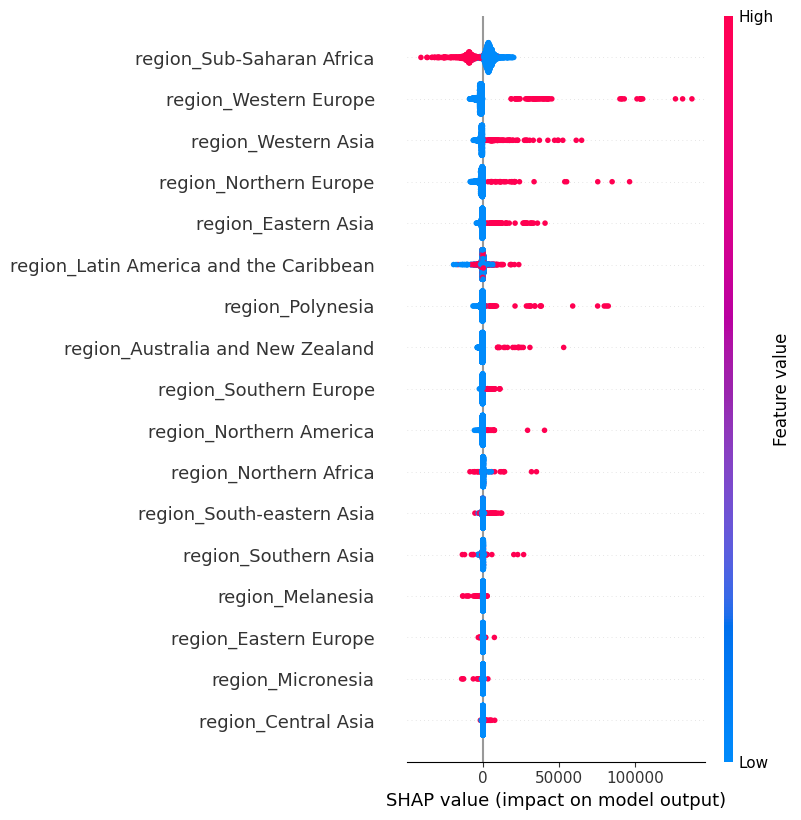

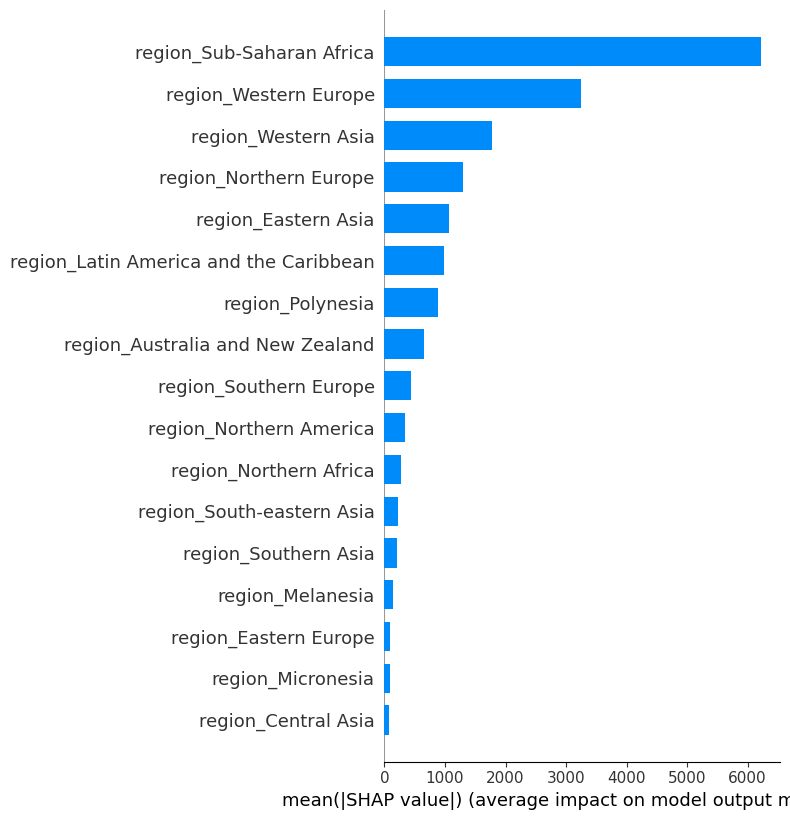

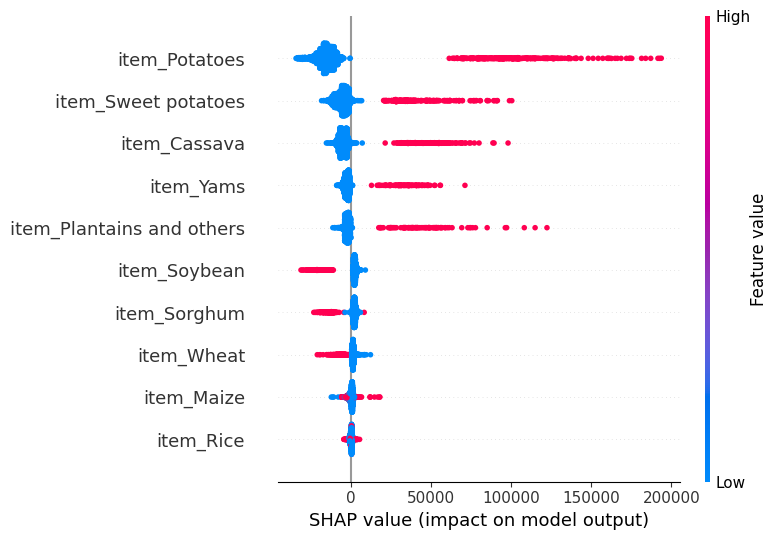

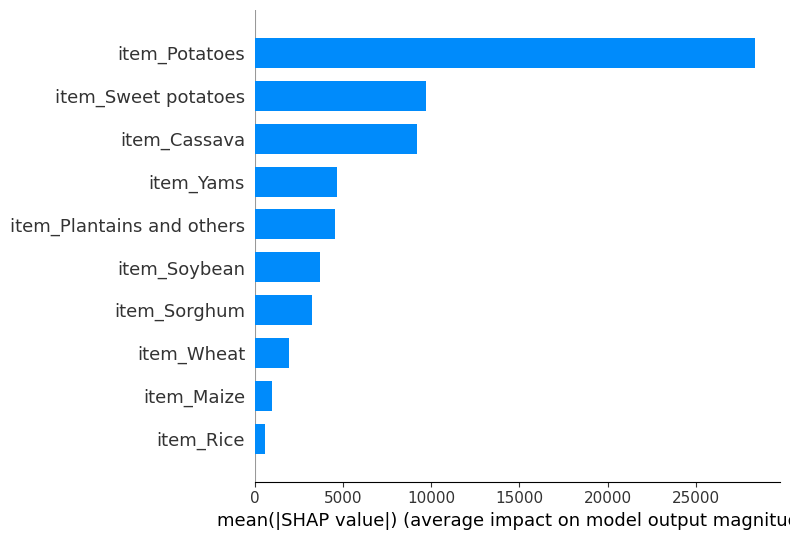

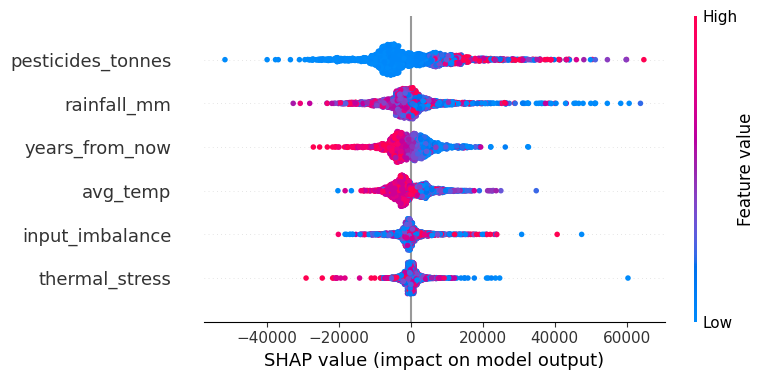

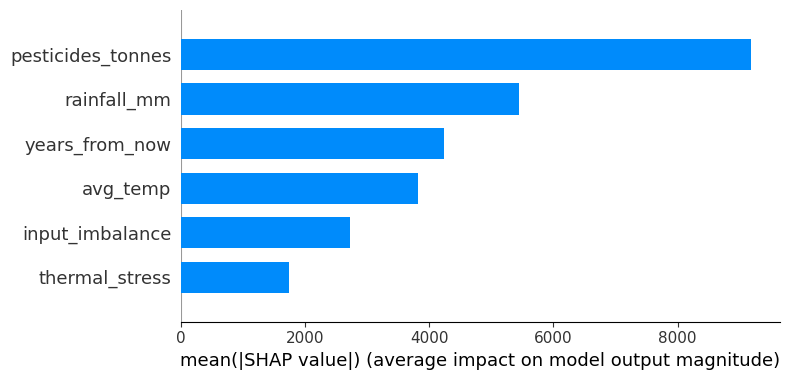

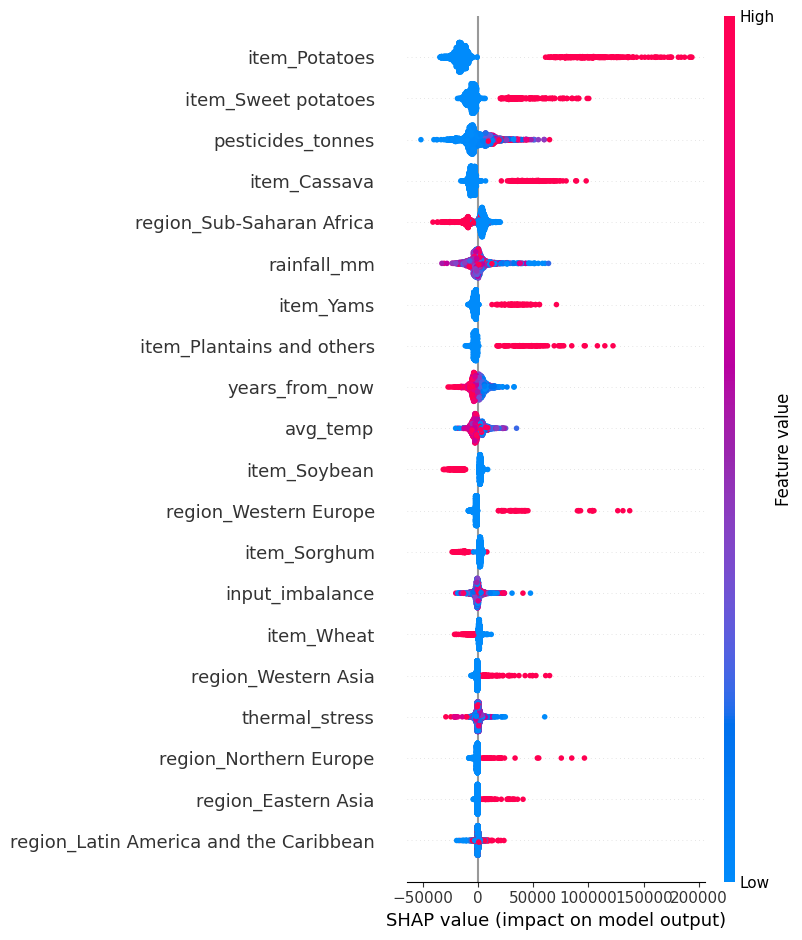

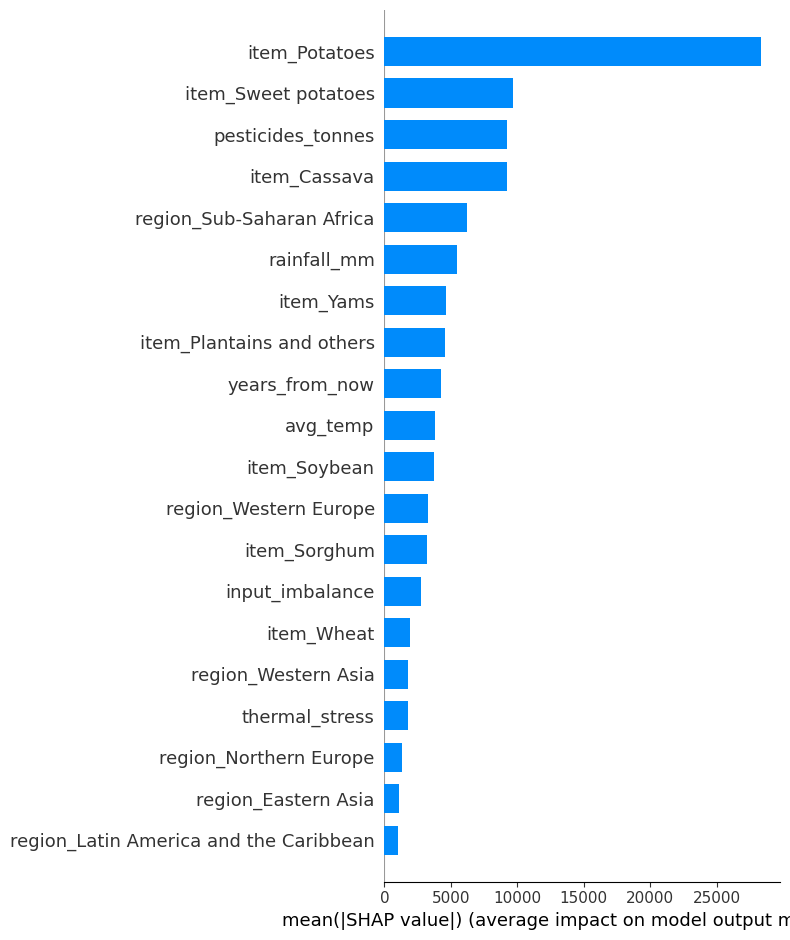

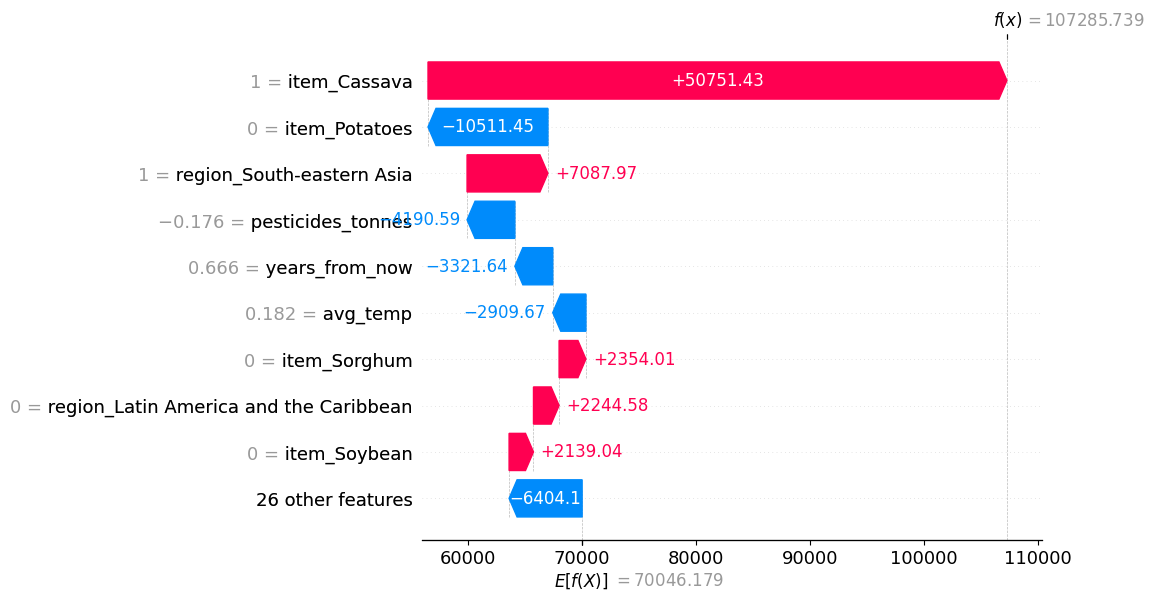

In [38]:
ARTIFACT_DIR = "../model/shap_randomforest_sample"

X_shap = joblib.load(os.path.join(ARTIFACT_DIR, "X_shap_sample.joblib"))
shap_values = joblib.load(os.path.join(ARTIFACT_DIR, "shap_values_sample.joblib"))
expected_value = joblib.load(os.path.join(ARTIFACT_DIR, "expected_value.joblib"))

# Noms plus lisibles
X_plot = X_shap.copy()
X_plot.columns = [
    col.replace("num__", "").replace("cat__", "")
    for col in X_plot.columns
]
# ========
# REGIONS
# ========
# On filtre les colonnes qui commencent par 'region'
region_cols = [col for col in X_plot.columns if col.startswith("region")]
region_indices = [X_plot.columns.get_loc(col) for col in region_cols]

# On extrait les valeurs SHAP correspondantes
shap_values_regions = shap_values[:, region_indices]
X_regions = X_plot[region_cols]

# 1. Importance globale (Bee swarm) uniquement pour les régions
shap.summary_plot(shap_values_regions, X_regions)

# 2. Importance bar (Classement des régions les plus influentes)
shap.summary_plot(shap_values_regions, X_regions, plot_type="bar")

# ======
# Item
# ======

# On filtre les colonnes qui commencent par 'item'
item_cols = [col for col in X_plot.columns if col.startswith("item")]
item_indices = [X_plot.columns.get_loc(col) for col in item_cols]

# On extrait les valeurs SHAP correspondantes
shap_values_item = shap_values[:, item_indices]
X_item = X_plot[item_cols]

# 1. Importance globale (Bee swarm) uniquement pour les items
shap.summary_plot(shap_values_item, X_item)

# 2. Importance bar (Classement des items les plus influentes)
shap.summary_plot(shap_values_item, X_item, plot_type="bar")

# ======================
# Variables climatiques
# ======================
num_cols = ["avg_temp", "rainfall_mm", "pesticides_tonnes", "years_from_now", "input_imbalance", "thermal_stress"]
# On récupère les indices directement depuis X_plot pour être sûr de l'alignement avec shap_values
climate_indices = [X_plot.columns.get_loc(col) for col in num_cols]

# On extrait les valeurs SHAP correspondantes
shap_values_climate = shap_values[:, climate_indices]
X_climate = X_plot[num_cols]

# 1. Importance globale (Bee swarm) pour le climat/numérique
shap.summary_plot(shap_values_climate, X_climate)

# 2. Importance bar
shap.summary_plot(shap_values_climate, X_climate, plot_type="bar")
# ==========
# AU GLOBAL
# ==========
# 1. Importance globale
shap.summary_plot(shap_values, X_plot)

# 2. Importance bar
shap.summary_plot(shap_values, X_plot, plot_type="bar")

base_value = expected_value.item() if hasattr(expected_value, "item") else float(expected_value)
# 3. Waterfall sur une observation
idx = 68
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[idx],
        base_values=base_value,
        data=X_plot.iloc[idx],
        feature_names=X_plot.columns
    )
)